In [10]:
import numpy as np

In [11]:
from graphviz import Digraph

def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right
  
  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
    if n._op:
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._op, label = n._op)
      # and connect this node to it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot

In [12]:
class Value:
    def __init__(self, data, label = '', parents=(), _op=None):
        self.data = data
        self._prev = set(parents)
        self.label = label
        self.grad = 0
        self._op = _op
        self._backward = lambda: None
    def __add__(self, other):
        if not isinstance(other, Value):
            other = Value(other)
        result = Value(data = self.data + other.data, parents=(self, other), _op='+')
        def _backward():
            self.grad += result.grad
            other.grad += result.grad
        result._backward = _backward
        return result
    def __mul__(self, other):
        if not isinstance(other, Value):
            other = Value(other)
        result = Value(data = self.data * other.data, parents=(self, other), _op='*')
        def _backward():
            self.grad += result.grad * other.data
            other.grad += result.grad * self.data
        result._backward = _backward
        return result
    def __neg__(self):
        return self * -1
    def __sub__(self, other):
        return self + (-other)
    def tanh(self):
        tanh = lambda x: (np.e ** (2*x) - 1)/(np.e ** (2*x) + 1)
        result = Value(data = tanh(self.data), parents=(self,), _op='tanh')
        def _backward():
            self.grad += (1 - result.data ** 2) * result.grad
        result._backward = _backward
        return result
    def exp(self): 
        result = Value(np.e**self.data, parents=(self,), _op='exp')
        def _backward():
            # print(result.data, result.grad)
            self.grad += result.data * result.grad
        result._backward = _backward
        return result
    def __pow__(self, other):
        # Here other is int or float, not Value
        result = Value(self.data ** other, parents=(self,), _op='pow')
        def _backward():
            self.grad += other * result.data / self.data * result.grad
        result._backward = _backward
        return result
    def __truediv__(self, other):
        if not isinstance(other, Value):
            other = Value(other)
        return self * other ** -1
    def __radd__(self, other):
        return self + other
    def __rmul__(self, other):
        return self * other
    def __repr__(self):
        return f"Value(data={self.data}, grad={self.grad}, label={self.label})"
    def zero_grad(self):
        # can be called on the final output in the training loop to clear all grads
        # works fine on intermediate values also, will delete all it's parent's grads (childrens?)
        if self.grad != 0: # so recursion does not repeat following multiple paths
            self.grad = 0
            for p in self._prev:
                p.zero_grad()
    def backward(self, is_result=True):
        self.grad = 1.0
        node_list = []
        def traverse(node):
            # print(node)
            for n in node._prev:
                if n not in node_list: # assuming no back edges (ie, acyclic)
                    traverse(n)
            node_list.append(node)
        traverse(self)
        node_list.reverse()
        # print("Topo Order:")
        # for ele in node_list:
        #     print(ele)
        for node in node_list:
            node._backward()

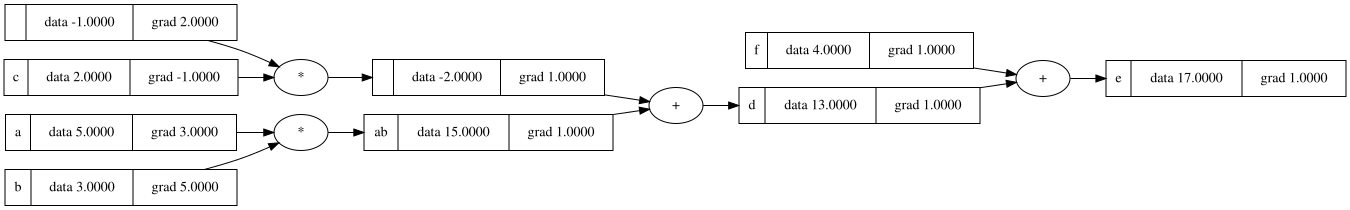

In [13]:
a = Value(5)
a.label = 'a'
b = Value(3)
b.label = 'b'
c = Value(2)
c.label = 'c'
ab = a * b
ab.label = 'ab'
d = ab + (-c)
d.label = 'd'
f = Value(4)
f.label = 'f'
e = d + f
e.label = 'e'

e.zero_grad()
e.backward()
draw_dot(e)

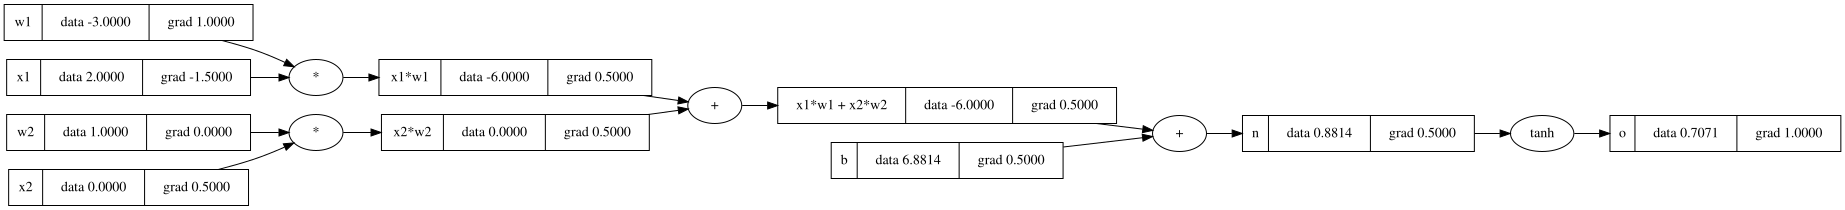

In [6]:


# inputs x1,x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1,w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.8813735870195432, label='b')
# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'o'
o.zero_grad()
o.backward()

draw_dot(o)

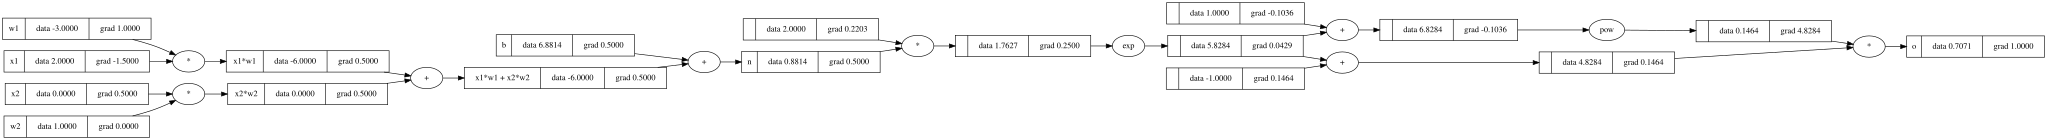

In [15]:


# inputs x1,x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1,w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.8813735870195432, label='b')
# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
# # ----
e = (2*n).exp()
o = (e - 1) / (e + 1)
# ----
o.label = 'o'
o.zero_grad()
o.backward()
draw_dot(o)



In [17]:
import torch


In [22]:
x1 = torch.tensor(2., requires_grad=True)
x2 = torch.tensor(0., requires_grad=True)
w1 = torch.tensor(-3., requires_grad=True)
w2 = torch.tensor(1., requires_grad=True)
b = torch.tensor(6.8814, requires_grad=True)
o = torch.tanh(x1*w1 + x2*w2 + b)
o


tensor(0.7071, grad_fn=<TanhBackward0>)

In [24]:
o.backward()

In [31]:
o.grad

/tmp/ipykernel_98281/3391283232.py:1: UserWarning: The .grad attribute of a Tensor that is not a leaf Tensor is being accessed. Its .grad attribute won't be populated during autograd.backward(). If you indeed want the .grad field to be populated for a non-leaf Tensor, use .retain_grad() on the non-leaf Tensor. If you access the non-leaf Tensor by mistake, make sure you access the leaf Tensor instead. See github.com/pytorch/pytorch/pull/30531 for more information. (Triggered internally at /pytorch/build/aten/src/ATen/core/TensorBody.h:494.)
  o.grad


In [55]:
class Neuron:
    def __init__(self, n_in):
        self.weights = [Value(np.random.uniform(-1,1)) for i in range(n_in)]
        self.bias = Value(np.random.uniform(-1,1))
    def __call__(self, x):
        sum = 0 + self.bias
        assert len(x) == len(self.weights)
        for x,w in zip(x, self.weights):
            sum += x * w
        return sum
    def parameters(self):
        return self.weights + [self.bias]
    
class Layer:
    def __init__(self, in_dim, out_dim):
        self.neurons = [Neuron(in_dim) for n_idx in range(out_dim)]
    def __call__(self, x):
        return [n(x) for n in self.neurons]
    def parameters(self):
        params = []
        for n in self.neurons:
            params += n.parameters()
        return params
    
# class MLP:
#     def __init__(self, dim_list):
#         layers = [Layer(dim_list[dim_idx - 1], dim_list[dim_idx]) for dim_idx in range(1, len(dim_list))]



In [56]:
l = Layer(2,3)
l([2,3])

[Value(data=0.8883061066262439, grad=0, label=),
 Value(data=-3.7174161023282295, grad=0, label=),
 Value(data=0.41181659003033055, grad=0, label=)]

In [58]:
l.neurons[0].parameters()

[Value(data=0.6471304567047897, grad=0, label=),
 Value(data=-0.2020071410187365, grad=0, label=),
 Value(data=0.20006661627287392, grad=0, label=)]

In [59]:
dim_list = [2,3,5,2]
layers = [Layer(dim_list[dim_idx - 1], dim_list[dim_idx]) for dim_idx in range(1, len(dim_list))]
